# Alpaca Pilot Keyboard Map



In [62]:
import re, json
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def load_keymap_from_ts(ts_path: str, export_name: str = "defaultKeyMap") -> dict:
    """
    Pulls a plain string->string object literal out of a .ts file via regex
    and parses it as JSON. Works for a simple KeyMap; won't handle computed
    keys, comments inside the object literal, or non-string values.
    """
    text = Path(ts_path).read_text()
    pattern = rf"{export_name}\s*(?::\s*\w+\s*)?=\s*(\{{.*?\}})\s*;"
    match = re.search(pattern, text, re.DOTALL)
    if not match:
        raise ValueError(f"Could not find `{export_name}` object literal in {ts_path}")

    obj_literal = match.group(1)
    json_text = obj_literal.replace("'", '"')
    json_text = re.sub(r",\s*}", "}", json_text)  # drop trailing commas
    return json.loads(json_text)

# Adjust this path to wherever the notebook sits relative to your repo
key_map = load_keymap_from_ts('../pilot/src/composables/useKeyMap.ts')

In [63]:
# --- Config: keymap + category colors ---
import re
DARK_MODE = True

if DARK_MODE:
    BG_COLOR = '#1e1e1e'
    EDGE_COLOR = '#5f6368'
    TITLE_COLOR = '#E8EAED'
    SUBTITLE_COLOR = '#9AA0A6'
    PLAIN_KEY_COLOR = '#3c4043'
    PLAIN_TEXT_COLOR = '#9AA0A6'
else:
    BG_COLOR = 'white'
    EDGE_COLOR = '#3c4043'
    TITLE_COLOR = '#202124'
    SUBTITLE_COLOR = '#5F6368'
    PLAIN_KEY_COLOR = '#DADCE0'
    PLAIN_TEXT_COLOR = '#5F6368'

# Tweak these to change the palette
CATEGORY_COLORS = {
    'movement': '#4C8BF5',
    'speed':    '#34A853',
    'action':   '#FB8C00',
    'abort':    '#E53935',
    'nav':      '#8E5CD9',
    'plain':    PLAIN_KEY_COLOR,
}

MOVEMENT_CMDS = {'moveLeft', 'moveRight', 'moveUp', 'moveDown', 'moveCCW', 'moveCW', 'referenceFrame'}
ACTION_CMDS   = { 'centerGrid', 'findHome', 'resetSetPoint', 'toggleTracking', 'parkUnPark', 'syncGuiding', 'pulseGuiding', 'togglePEC', 'toggleMPA'}
NAV_CMDS      = {'dashboard', 'alignment', 'connect', 'settings', 'nearby', 'log', 'brightest', 'moons'}

def category_for(cmd):
    if cmd is None:
        return 'plain'
    if cmd in MOVEMENT_CMDS:
        return 'movement'
    if cmd.startswith('speed'):
        return 'speed'
    if cmd == 'abortSlew':
        return 'abort'
    if cmd in ACTION_CMDS:
        return 'action'
    if cmd in NAV_CMDS:
        return 'nav'
    return 'plain'

DISPLAY_CHAR = {
    'ArrowLeft': '\u2190', 'ArrowRight': '\u2192', 'ArrowUp': '\u2191', 'ArrowDown': '\u2193',
    'Escape': 'Esc', 'Backspace': 'Bksp',
}

def label_for(raw_key):
    return DISPLAY_CHAR.get(raw_key, raw_key.upper() if len(raw_key) == 1 else raw_key)

def split_camel(cmd):
    """Split long camelCase commands onto two lines so they fit on a keycap."""
    m = re.match(r'^([a-z]+)([A-Z].*)$', cmd)
    if m and len(cmd) > 2:
        return m.group(1), m.group(2)
    return cmd, None

In [64]:
# --- Geometry ---
# Row offsets are independent of the leading modifier key's width (Tab/Caps/Shift).
# That's what caused misalignment before: the row offset must be a small fixed
# stagger from the digit row, and the modifier key is drawn *ending* at that
# offset (so it overhangs left), not the row starting *after* the modifier.

GAP = 0.08
KH = 1.0
CORNER_RADIUS = 0.08

QWERTY_OFFSET = 0.5   # tweak these three to change the stagger amount
ASDF_OFFSET = 0.75
ZXCV_OFFSET = 1.25

row_defs = [
    # y, start_x, [(raw_key_or_None, width), ...]
    (4.15, -1.0, [
        ('Escape', 1.0),   # Escape shares the digit row, small gap after it
        ('1', 1), ('2', 1), ('3', 1), ('4', 1), ('5', 1), ('6', 1), ('7', 1), ('8', 1), ('9', 1), ('0', 1), ('-', 1), ('=', 1),
        ('Backspace', 2),
    ]),
    (3.0, QWERTY_OFFSET - 1.5, [
        ('Tab', 1.5), ('q', 1), ('w', 1), ('e', 1), ('r', 1), ('t', 1), ('y', 1), ('u', 1), ('i', 1), ('o', 1), ('p', 1), ('[', 1), (']', 1), ('\\', 1.5)
    ]),
    (1.85, ASDF_OFFSET - 1.75, [
        ('Caps', 1.75), ('a', 1), ('s', 1), ('d', 1), ('f', 1), ('g', 1), ('h', 1), ('j', 1), ('k', 1), ('l', 1), (';', 1), ("'", 1),
        ('Enter', 2.25),
    ]),
    (0.7, ZXCV_OFFSET - 2.25, [
        ('Shift', 2.25), ('z', 1), ('x', 1), ('c', 1), ('v', 1), ('b', 1), ('n', 1), ('m', 1), (',', 1), ('.', 1), ('/', 1),
        ('Shift', 2.0),
    ]),
    (-0.45, 0.0, [
        ('Ctrl', 1.5), ('Win', 1.25), ('Alt', 1.25), ('Space', 4.0), ('Alt', 1.25), ('Win', 1.25), ('Menu', 1.25), ('Ctrl', 1.5),
    ]),
]

ARROW_X0 = 14  # x position of the arrow-key cluster, right of the main block

def draw_key(ax, x, y, w, h, raw_key):
    if raw_key is None:
        return
    bound_key = ' ' if raw_key == 'Space' else raw_key
    cmd = key_map.get(bound_key)
    cat = category_for(cmd)
    face = CATEGORY_COLORS[cat]
    text_color = 'white' if cat != 'plain' else PLAIN_TEXT_COLOR

    box = FancyBboxPatch(
        (x, y), w - GAP, h - GAP,
        boxstyle=f"round,pad=0,rounding_size={CORNER_RADIUS}",
        linewidth=1.1, edgecolor=EDGE_COLOR, facecolor=face,
    )
    ax.add_patch(box)
    cx, cy = x + (w - GAP) / 2, y + (h - GAP) / 2

    if cmd:
        line1, line2 = split_camel(cmd)
        char_y = cy + (0.16 if line2 else 0.22)
        ax.text(cx, char_y, label_for(raw_key), ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_color)
        if line2:
            ax.text(cx, cy - 0.15, line1, ha='center', va='center',
                    fontsize=8, color=text_color, style='italic')
            ax.text(cx, cy - 0.32, line2, ha='center', va='center',
                    fontsize=8, color=text_color, style='italic')
        else:
            ax.text(cx, cy - 0.22, cmd, ha='center', va='center',
                    fontsize=8, color=text_color, style='italic')
    else:
        ax.text(cx, cy, label_for(raw_key), ha='center', va='center',
                fontsize=11, color=text_color)


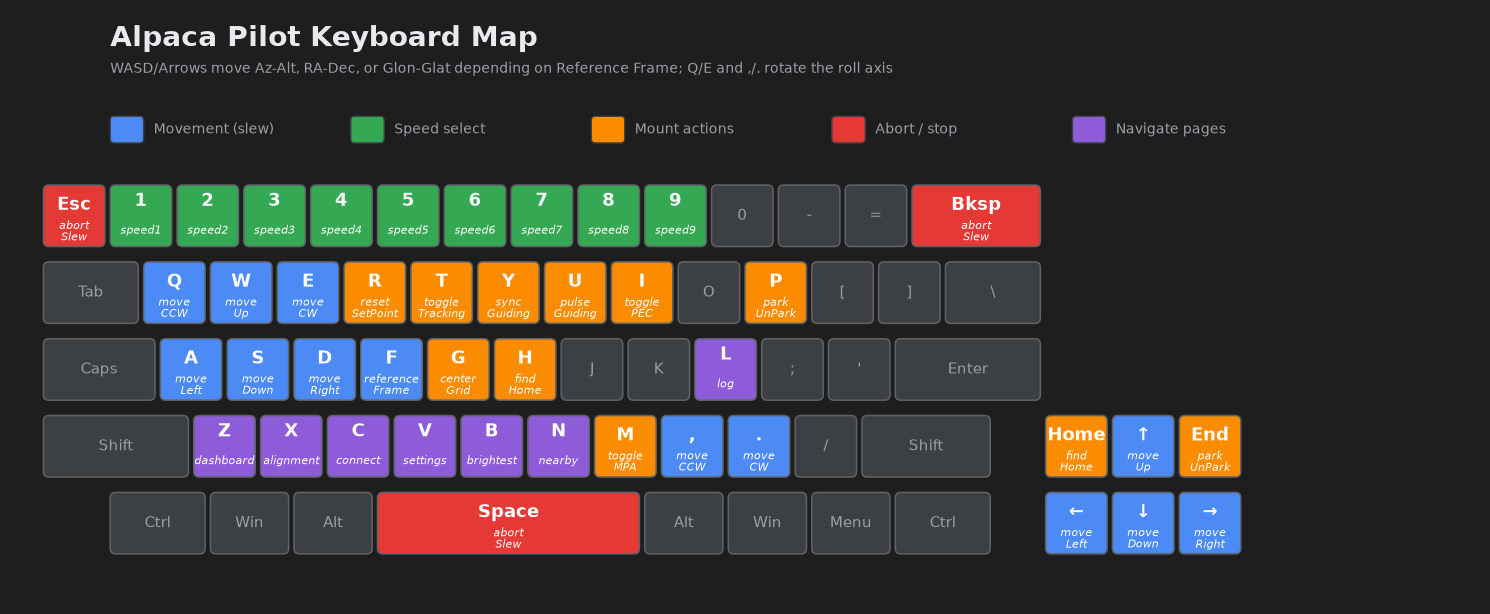

In [ ]:
# --- Build and render the figure ---

fig, ax = plt.subplots(figsize=(15, 6.8), facecolor=BG_COLOR)  # figure background
ax.set_facecolor(BG_COLOR) 

for y, start_x, keys in row_defs:
    x = start_x
    for raw_key, w in keys:
        draw_key(ax, x, y, w, KH, raw_key)
        x += w

# Arrow cluster
draw_key(ax, ARROW_X0 + 0.0, 0.7, 1.0, KH, 'Home')
draw_key(ax, ARROW_X0 + 1.0, 0.7, 1.0, KH, 'ArrowUp')
draw_key(ax, ARROW_X0 + 2.0, 0.7, 1.0, KH, 'End')
draw_key(ax, ARROW_X0 + 0.0, -0.45, 1.0, KH, 'ArrowLeft')
draw_key(ax, ARROW_X0 + 1.0, -0.45, 1.0, KH, 'ArrowDown')
draw_key(ax, ARROW_X0 + 2.0, -0.45, 1.0, KH, 'ArrowRight')

# Legend
legend_items = [
    ('movement', 'Movement (slew)'),
    ('speed', 'Speed / Zoom select'),
    ('action', 'Mount actions'),
    ('abort', 'Abort / stop'),
    ('nav', 'Navigate pages'),
]
ly = 5.7
for i, (cat, text) in enumerate(legend_items):
    swatch_x = i * 3.6
    ax.add_patch(FancyBboxPatch((swatch_x, ly), 0.5, 0.4, boxstyle="round,pad=0,rounding_size=0.06",
                                 linewidth=1, edgecolor='#3c4043', facecolor=CATEGORY_COLORS[cat]))
    ax.text(swatch_x + 0.65, ly + 0.2, text, ha='left', va='center', fontsize=10, color=SUBTITLE_COLOR)

ax.text(0.0, 7.15, 'Alpaca Pilot Keyboard Map', fontsize=20, fontweight='bold', color=TITLE_COLOR)
ax.text(0.0, 6.75, 'WASD/Arrows move Az-Alt, RA-Dec, or Glon-Glat depending on Reference Frame; Q/E and ,/. rotate the roll axis',
        fontsize=10, color=SUBTITLE_COLOR)

ax.set_xlim(-1.5, 20.5)  # widened to fit the arrow cluster (ARROW_X0 + 3 = 19.6) — was clipping at 18.0
ax.set_ylim(-1.2, 7.7)
ax.set_aspect('equal')
ax.axis('off')


plt.tight_layout()
plt.show()

# To export a static PNG:
fig.savefig('keyboard-map.png', dpi=200, facecolor=BG_COLOR)